In [129]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score, classification_report, roc_auc_score, roc_curve
import xgboost as xgb
from xgboost import XGBClassifier
from scipy.stats import randint
from scipy.stats import uniform
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import StratifiedKFold
from lightgbm import LGBMClassifier
import joblib
from joblib import dump, load
import json
import re

In [333]:
df=pd.read_csv(r'TZ.csv', index='ID' )

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 15000 entries, 0 to 14999
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID_клиента          15000 non-null  float64
 1   фамилия             15000 non-null  object 
 2   кредитный_рейтинг   15000 non-null  float64
 3   город               15000 non-null  object 
 4   пол                 15000 non-null  object 
 5   возраст             15000 non-null  float64
 6   стаж_в_банке        15000 non-null  float64
 7   баланс_депозита     5316 non-null   float64
 8   число_продуктов     15000 non-null  float64
 9   есть_кредитка       15000 non-null  float64
 10  активный_клиент     15000 non-null  float64
 11  оценочная_зарплата  15000 non-null  float64
 12  ушел_из_банка       15000 non-null  float64
dtypes: float64(10), object(3)
memory usage: 1.6+ MB


In [285]:
df.describe()

,ID_клиента,кредитный_рейтинг,возраст,стаж_в_банке,баланс_депозита,число_продуктов,есть_кредитка,активный_клиент,оценочная_зарплата,ушел_из_банка,город_Алматы,город_Астана,город_Атырау,пол_Female,пол_Male
count,1.500000e+04,15000.000000,15000.000000,15000.000000,5316.000000,15000.000000,15000.000000,15000.000000,1.500000e+04,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,1.579653e+07,658.851467,37.888000,5.033333,121681.886227,1.590733,0.783200,0.500200,1.181348e+05,0.203867,0.598067,0.221400,0.180533,0.442800,0.557200
std,1.270937e+07,72.587026,8.257409,2.808359,22875.768239,0.535587,0.412079,0.500017,4.680311e+04,0.402884,0.490305,0.415203,0.384644,0.496734,0.496734
min,1.556578e+07,431.000000,18.000000,0.000000,753.370000,1.000000,0.000000,0.000000,1.158000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.563449e+07,602.000000,32.000000,3.000000,106392.525000,1.000000,1.000000,0.000000,8.362960e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.569053e+07,662.000000,37.000000,5.000000,122570.690000,2.000000,1.000000,1.000000,1.235878e+05,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000
75%,1.575758e+07,709.000000,42.000000,7.000000,137226.870000,2.000000,1.000000,1.000000,1.575585e+05,0.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,1.572242e+09,850.000000,74.000000,10.000000,187530.660000,4.000000,1.000000,1.000000,1.557802e+06,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


# EDA and Data Preparation+Feature Engineering (small)

In [12]:
df.город.value_counts()

город
Алматы    8971
Астана    3321
Атырау    2708
Name: count, dtype: int64

In [134]:
enc = OneHotEncoder(handle_unknown='ignore')
enc.fit(df[['город','пол']]) 

,categories,'auto'
,drop,None
,sparse_output,True
,dtype,<class 'numpy.float64'>
,handle_unknown,'ignore'
,min_frequency,None
,max_categories,None
,feature_name_combiner,'concat'


In [398]:
encoded=encoder.transform(df[['город','пол']]).toarray()

In [397]:
encoder.get_feature_names_out(['город','пол'])

array(['город_Алматы', 'город_Астана', 'город_Атырау', 'пол_Female',
       'пол_Male'], dtype=object)

In [137]:
encoded=pd.DataFrame(encoded, columns=enc.get_feature_names_out(['город','пол']))

In [395]:
joblib.dump(enc, 'encoder.pkl')

['encoder.pkl']

In [139]:
encoded=pd.DataFrame(encoded, columns=enc.get_feature_names_out(['город','пол']))
df=pd.concat([df, encoded], axis=1)# ignore_index=True)

In [142]:
df1=df.copy()

In [140]:
df1.drop(['город','фамилия','пол'], axis=1, inplace=True)

In [51]:
df1.кредитный_рейтинг.value_counts()

кредитный_рейтинг
678.0    260
684.0    195
705.0    178
850.0    168
651.0    165
        ... 
822.0      1
788.0      1
515.0      1
459.0      1
795.0      1
Name: count, Length: 379, dtype: int64

In [141]:
df1['balance_null']=df.баланс_депозита.isna()

<Axes: >

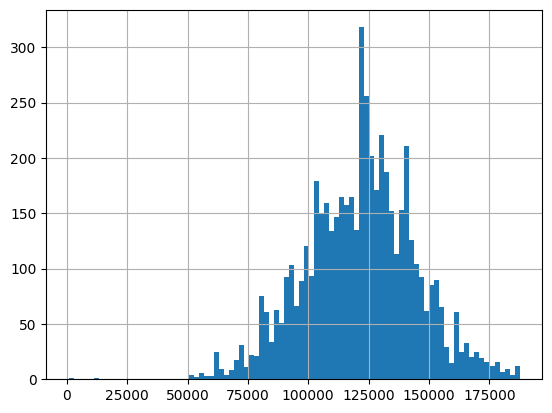

In [66]:
df.баланс_депозита.hist(bins=90)

In [143]:
df1.баланс_депозита.fillna(df1.баланс_депозита.median(), inplace=True)

/tmp/ipykernel_14275/3811791199.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df1.баланс_депозита.fillna(df1.баланс_депозита.median(), inplace=True)


In [70]:
df1['balance_null']=df1['balance_null'].astype(int)
#Small feature engineering.
#We can't just replace null with median the fact that the value were null is also useful information

Index(['ID_клиента', 'кредитный_рейтинг', 'возраст', 'стаж_в_банке',
       'баланс_депозита', 'число_продуктов', 'есть_кредитка',
       'активный_клиент', 'оценочная_зарплата', 'ушел_из_банка',
       'город_Алматы', 'город_Астана', 'город_Атырау', 'пол_Female',
       'пол_Male', 'balance_null'],
      dtype='object')

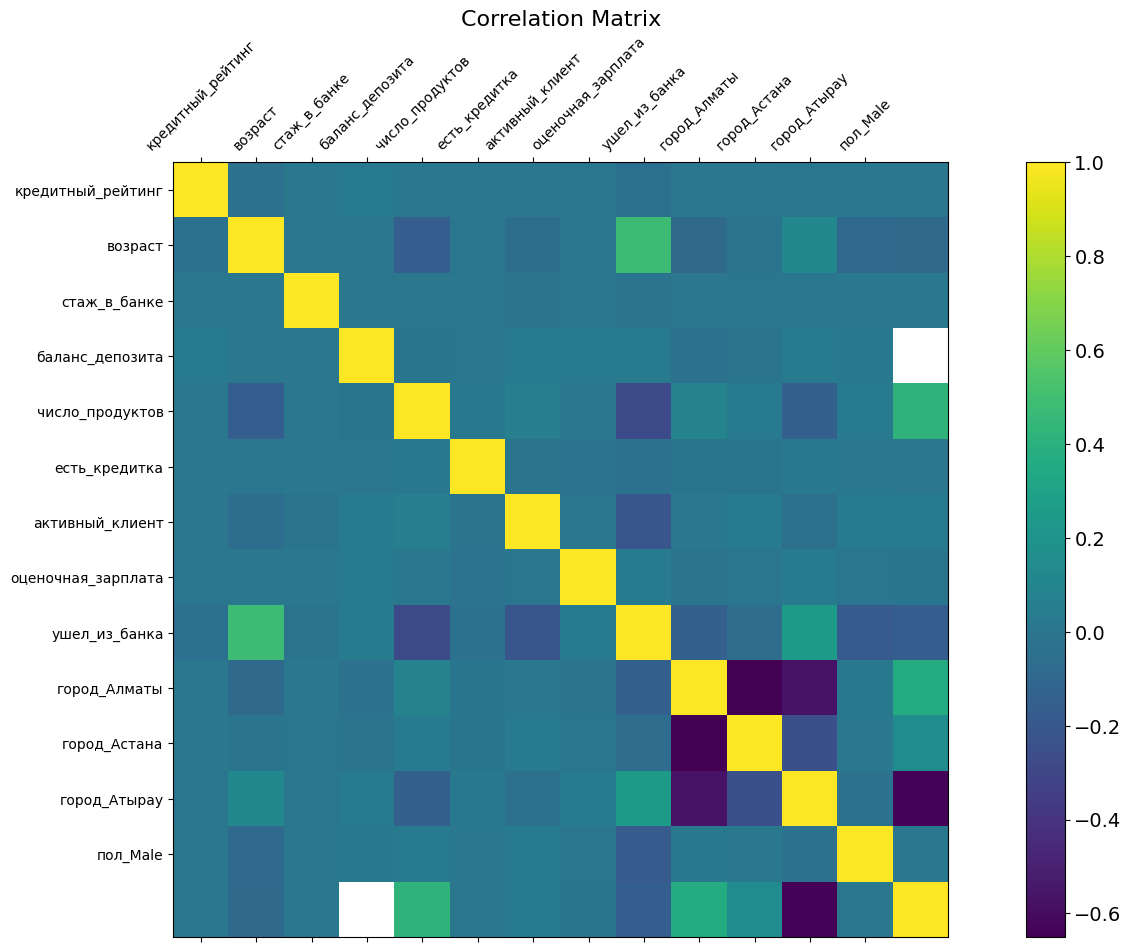

In [88]:
df=df[['кредитный_рейтинг', 'возраст', 'стаж_в_банке',
       'баланс_депозита', 'число_продуктов', 'есть_кредитка',
       'активный_клиент', 'оценочная_зарплата', 'ушел_из_банка',
       'город_Алматы', 'город_Астана', 'город_Атырау', 
       'пол_Male', 'balance_null']]
df = plt.figure(figsize=(20, 10))
plt.matshow(df.corr(), fignum=f.number)
plt.xticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=10, rotation=45)
plt.yticks(range(df.select_dtypes(['number']).shape[1]), df.select_dtypes(['number']).columns, fontsize=10)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16);

Looking at the correlation matrix we can see that:
* the older the person the higher the probability to leave the bank
* the more product client use the less likely they will leave
* The lower the salary the more client is likely to leave the bank

As we encoded some categorical variables they of course will show multicollinearity 

<Axes: >

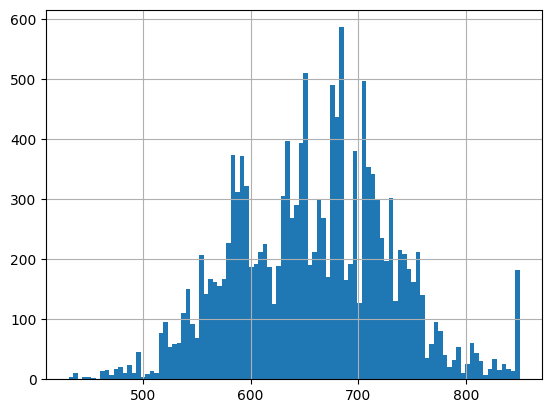

In [127]:
df1.кредитный_рейтинг.hist(bins=100)

<Axes: >

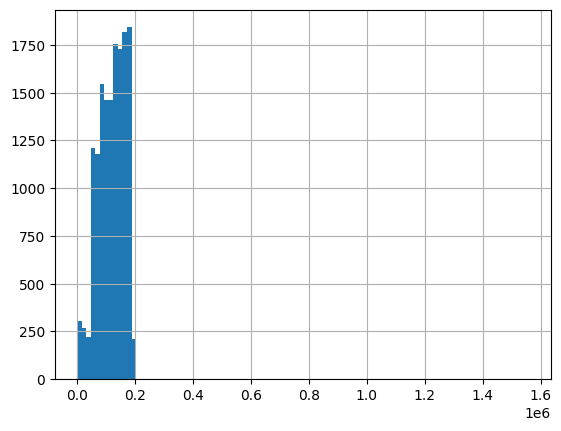

In [129]:
df1.оценочная_зарплата.hist(bins=100)

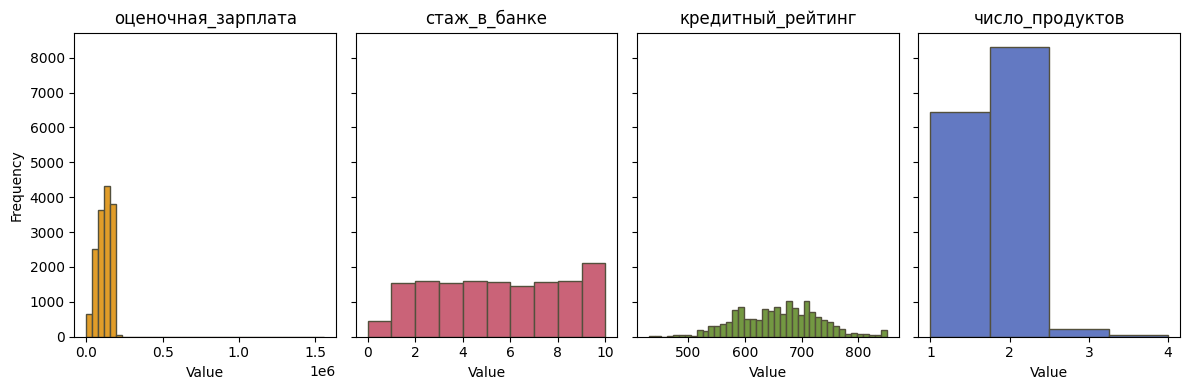

In [179]:

data1 = df1.оценочная_зарплата
data2 = df1.стаж_в_банке
data3 = df1.кредитный_рейтинг
data4 = df1.число_продуктов
fig, axes = plt.subplots(1, 4, figsize=(12, 4), sharey=True)
boundaries='#53503c'

axes[0].hist(data1, bins=40, color='#E19D29', edgecolor=boundaries)
axes[0].set_title('оценочная_зарплата')
axes[0].set_xlabel('Value')
axes[0].set_ylabel('Frequency')

axes[1].hist(data2, bins=10, color='#CA6378', edgecolor=boundaries)
axes[1].set_title('стаж_в_банке')
axes[1].set_xlabel('Value')

axes[2].hist(data3, bins=40, color='#739842', edgecolor=boundaries)
axes[2].set_title('кредитный_рейтинг')
axes[2].set_xlabel('Value')

axes[3].hist(data4, bins=4, color='#6379C2', edgecolor=boundaries)  #6379C2
axes[3].set_title('число_продуктов')
axes[3].set_xlabel('Value')

plt.tight_layout() 
plt.show()


<Axes: xlabel='ушел_из_банка'>

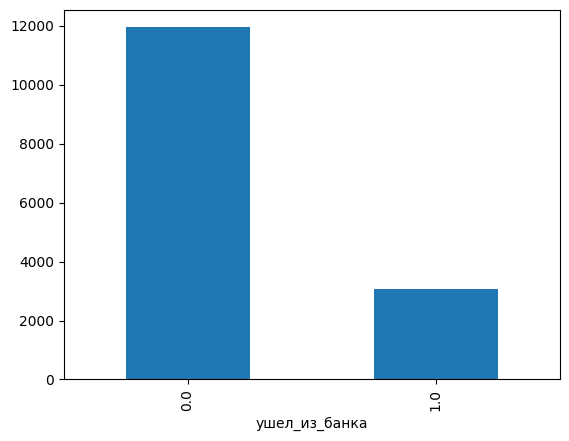

In [401]:
df1.ушел_из_банка.value_counts().plot(kind='bar')

* As we can see we have a reasonable imblance. Thus we need to make a stratified split so that proportion of classes in train and test will be the same

In [179]:
df1.drop(['ID_клиента'], axis=1, inplace=True)
test_df=pd.concat([df1.loc[df1['ушел_из_банка']==0].sample(frac=0.15), df1.loc[df1['ушел_из_банка']==1].sample(frac=0.15)])
train_df=df1[~df1.isin(test_df)].dropna()

### Scaling

In [180]:
cols_to_scale=['кредитный_рейтинг', 'возраст', 'стаж_в_банке', 'баланс_депозита',
       'оценочная_зарплата']

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

train_df[cols_to_scale] = scaler.fit_transform(train_df[cols_to_scale])

    

In [182]:
test_df[cols_to_scale] = scaler.transform(test_df[cols_to_scale])

### Spliting to train and test

In [183]:
y_train=train_df['ушел_из_банка']
X_train=train_df.drop(['ушел_из_банка'], axis=1) 
y_test=test_df['ушел_из_банка']
X_test=test_df.drop(['ушел_из_банка'], axis=1) 

# Training models

## Random Forest Classifier model

In [186]:
rfc = RandomForestClassifier(n_estimators=100, random_state=1)
rfc.fit(X_train, y_train)
cv_results = cross_val_score(rfc, X_train, y_train, cv=10, scoring='recall')

In [187]:
cv_results

array([0.67181467, 0.67692308, 0.61153846, 0.59230769, 0.61538462,
       0.66153846, 0.68461538, 0.68461538, 0.7       , 0.68461538])

In [277]:
y_pred_rf=rfc.predict(X_test)
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

         0.0       0.91      0.96      0.94      1791
         1.0       0.81      0.65      0.72       459

    accuracy                           0.90      2250
   macro avg       0.86      0.81      0.83      2250
weighted avg       0.89      0.90      0.89      2250



ROC AUC score: 0.9216


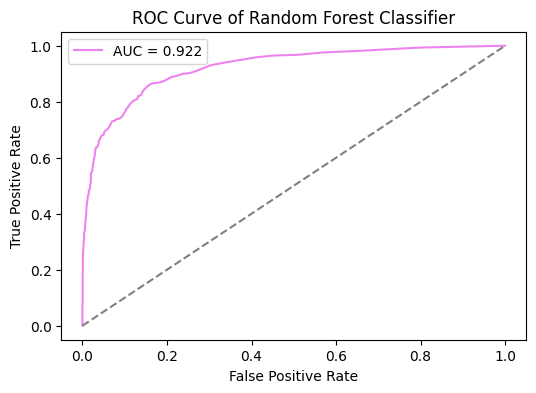

In [295]:
y_pred_proba = rfc.predict_proba(X_test)[:, 1]  # probability for class 1

auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC score: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='violet')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of Random Forest Classifier")
plt.legend()
plt.show()

## LightGBM model

In [356]:
lgbm = LGBMClassifier(
    objective="binary",
    boosting_type="gbdt",
    n_estimators=1000,
    learning_rate=0.05,
    num_leaves=31,          
    max_depth=-1,           
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1
)


In [357]:
lgbm.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 2599, number of negative: 10151
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.013303 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 850
[LightGBM] [Info] Number of data points in the train set: 12750, number of used features: 14
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.203843 -> initscore=-1.362445
[LightGBM] [Info] Start training from score -1.362445


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.05
,n_estimators,1000
,subsample_for_bin,200000
,objective,'binary'
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [359]:
# save model
joblib.dump(lgbm, 'lgb.pkl')
# load model
gbm_pickle = joblib.load('lgb.pkl')


In [290]:
y_pred_lgbm=lgbm.predict(X_test)
print(classification_report(y_test, y_pred_lgbm))

              precision    recall  f1-score   support

         0.0       0.92      0.95      0.93      1791
         1.0       0.78      0.67      0.72       459

    accuracy                           0.89      2250
   macro avg       0.85      0.81      0.83      2250
weighted avg       0.89      0.89      0.89      2250



ROC AUC score: 0.9167


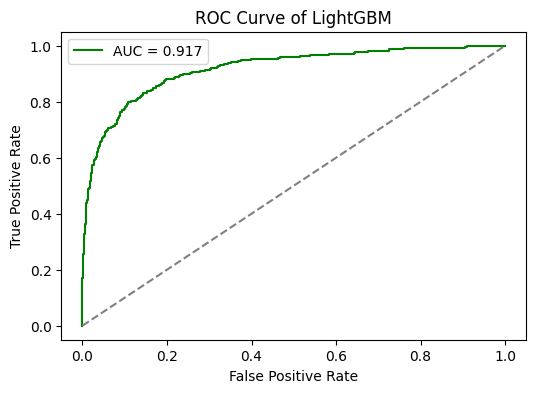

In [294]:

y_pred_proba = lgbm.predict_proba(X_test)[:, 1] 

auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC score: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='green')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of LightGBM")
plt.legend()
plt.show()


In [386]:
lgbm.feature_importances_ 

array([6786, 4403, 2767, 3890,  881,  525,  872, 6826,  537,  311,  524,
        736,  369,  573], dtype=int32)

## XGBoost Model

In [263]:

#parameters)))
params = {
            'objective':'binary:logistic',
            'max_depth': 7,
            'alpha': 10,
            'learning_rate': 0.5,
            'n_estimators':3000
        }         
           
# model's instance)          
xgb_clf = XGBClassifier(**params)

# fit 
xgb_clf.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [265]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score, classification_report
y_pred=xgb_clf.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.91      0.96      0.94      1791
         1.0       0.81      0.65      0.72       459

    accuracy                           0.90      2250
   macro avg       0.86      0.81      0.83      2250
weighted avg       0.89      0.90      0.89      2250



ROC AUC score: 0.9263


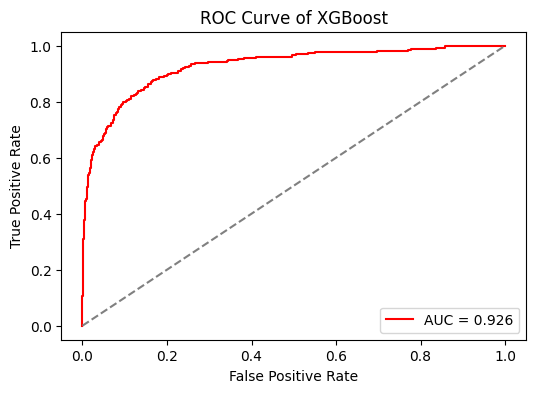

In [293]:
y_pred_proba = xgb_clf.predict_proba(X_test)[:, 1]  

auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC score: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}", color='red')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of XGBoost")
plt.legend()
plt.show()


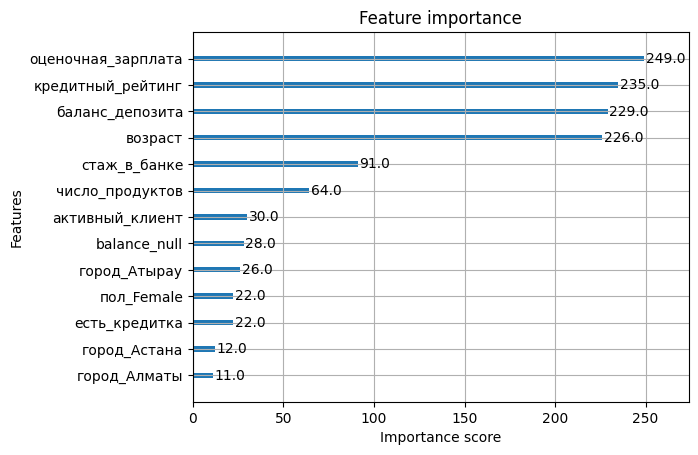

<Figure size 1600x1200 with 0 Axes>

In [284]:
xgb.plot_importance(xgb_clf)
plt.figure(figsize = (16, 12))
plt.show()

# Fine Tuning

## Finetuning XGBoost Model using Random Search CV

In [309]:
cv=StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

xgb = XGBClassifier(
    n_estimators=2000,
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=42,
    tree_method="hist",
    auto_class_weights='Balanced'
)

param_dist = {
    "learning_rate": uniform(0.1, 0.5),
    "max_depth": randint(5, 9),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_lambda": uniform(0.5, 2.0),
    'reg_alpha':uniform(0.0, 1.0)
}

search = RandomizedSearchCV(
    xgb,
    param_dist,
    n_iter=40,
    scoring="recall",
    cv=cv,
    n_jobs=-1,
    random_state=42
)

search.fit(X_train, y_train)


/opt/conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [10:20:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "auto_class_weights" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [10:20:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "auto_class_weights" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [10:20:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "auto_class_weights" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [10:20:49] WARNING: /workspace/src/learner.cc:738: 
Parameters: { "auto_class_weights" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/opt/conda/lib/python3.11/site-packages/xgboost/training.py:183: UserWarning: [10:20:49] WARNING

,estimator,"XGBClassifier...obs=None, ...)"
,param_distributions,"{'colsample_bytree': <scipy.stats....x7f59a0fc5450>, 'learning_rate': <scipy.stats....x7f598c57d790>, 'max_depth': <scipy.stats....x7f59a045e790>, 'reg_alpha': <scipy.stats....x7f59a1037850>, ...}"
,n_iter,40
,scoring,'recall'
,n_jobs,-1
,refit,True
,cv,StratifiedKFo... shuffle=True)
,verbose,0
,pre_dispatch,'2*n_jobs'
,random_state,42
,error_score,nan


In [310]:
search.best_params_

{'colsample_bytree': np.float64(0.7173952698872152),
 'learning_rate': np.float64(0.10703991135754223),
 'max_depth': 7,
 'reg_alpha': np.float64(0.7068573438476171),
 'reg_lambda': np.float64(1.9580143360819746),
 'subsample': np.float64(0.9085081386743783)}

In [311]:
search.cv_results_["mean_test_score"].mean()

np.float64(0.6616661345411347)

In [312]:

params = search.best_params_        

xgb_clf_cv = XGBClassifier(**params)

xgb_clf_cv.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,np.float64(0.7173952698872152)
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [313]:
from sklearn.metrics import accuracy_score, recall_score, precision_score, roc_auc_score, classification_report
y_pred_cv=xgb_clf_cv.predict(X_test)
print(classification_report(y_test, y_pred_cv))

              precision    recall  f1-score   support

         0.0       0.91      0.96      0.94      1791
         1.0       0.82      0.63      0.71       459

    accuracy                           0.90      2250
   macro avg       0.86      0.80      0.82      2250
weighted avg       0.89      0.90      0.89      2250



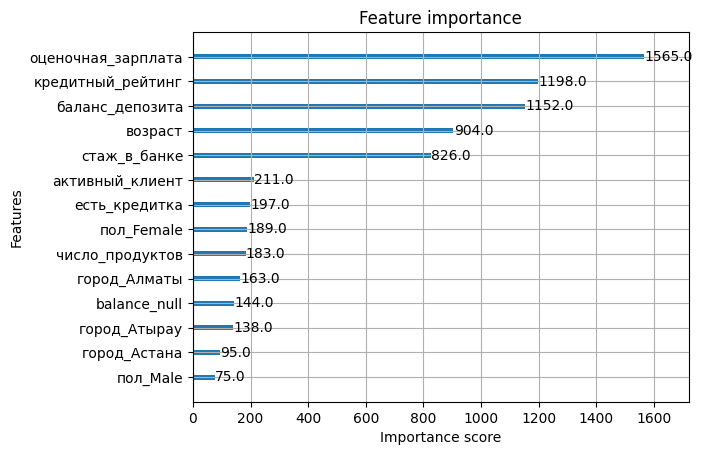

<Figure size 1600x1200 with 0 Axes>

In [314]:
xgb.plot_importance(xgb_clf_cv)
plt.figure(figsize = (16, 12))
plt.show()

ROC AUC score: 0.9258


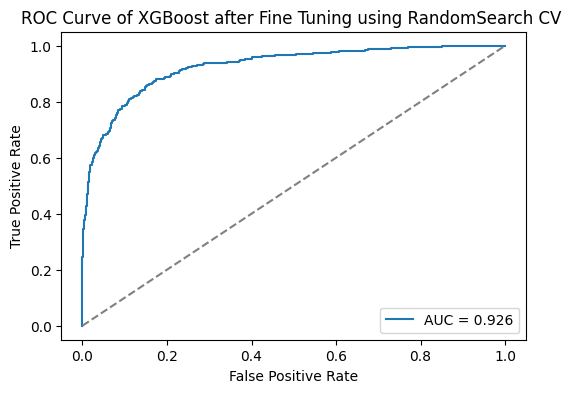

In [315]:

y_pred_proba = xgb_clf_cv.predict_proba(X_test)[:, 1]  # probability for class 1

auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC AUC score: {auc:.4f}")

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle='--', color='gray')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of XGBoost after Fine Tuning using RandomSearch CV ")
plt.legend()
plt.show()

#### !!! As we observe Fine Tuning did not improve but rather dicreased the recall rate and a bit ROC AUC score . Means our initial randomly chosen parameters were already good for XGBoost.

## Fine Tuning LightGBM Model using RandomSearchCV

In [323]:
cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lgbm=LGBMClassifier(n_estimators=500, 
                    objective='binary',
                    boosting_type="gbdt", 
                    random_state=42, 
                    n_jobs=-1)

param_dist = {
    "learning_rate": uniform(0.1, 0.5),
    "max_depth": randint(5, 9),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "reg_lambda": uniform(0.5, 2.0),
    'reg_alpha':uniform(0.0, 1.0),
    'num_leaves':randint(20, 50)
}


search=RandomizedSearchCV(lgbm, 
                          param_dist, 
                          cv=cv, 
                          n_iter=20, 
                          scoring='recall', 
                          n_jobs=-1,
                         verbose=2)

search.fit(X_train, y_train)
#This is actually takes a lot to wait and i decided to continue with LightGBM without Fine Tuning              

Fitting 5 folds for each of 20 candidates, totalling 100 fits


KeyboardInterrupt: 

In [322]:
search.best_params_

AttributeError: 'RandomizedSearchCV' object has no attribute 'best_params_'

# Conclusion

* Both Random Forest and XGBoost and even Fine-Tuned XGBoost could not shw the precision as high as LightGBM with randomly chosen parameters did. Thus I decided to continue with LightGBM model )))